Null Hypothesis (H0): Pa = Pb ; There will no significant difference in the proportion of people who see the each ad and click on each ad.

Alternative Hypothesis (Ha): Pb > Pa ; There is a signficant difference in the amount of people who click the ad when it is presented with the B logo.

For: 
    Pa: Proportion of people who clicked the A logo after viewing the ad ; Pa = P1\
    Pb: Proportion of people who clicked the B logo after viewing the ad ; Pb = P2




In [198]:
import numpy as np
from scipy.stats import norm

#x1
clicksA = 500
#x2
clicksB = 550
viewsA = 1000
viewsB = 1000


clicksC = 580
viewsC = 1000
pa = clicksA / viewsA

pb = clicksB / viewsB
p2 = clicksC / viewsC
pHat = (clicksA + clicksB) / (viewsA + viewsB)

pHatWIF = (clicksA + clicksC) / (viewsA + viewsC)

standardError = np.sqrt(pHat*(1-pHat)*((1/viewsA)+(1/viewsB)))

se = np.sqrt(pHatWIF*(1-pHatWIF)*((1/viewsA)+(1/viewsC)))
#since Ha is pb > pa, switch the observed difference so we can see if our Ha will not be rejected
z_score = (pb - pa)/standardError
print("The Zscore: ",z_score)
print(z_score)

whatifz_score = (p2 - pa) /se
print("If the Blogo had 580 clicks and A still had 500 the zscore would be:",whatifz_score)

pValue = 1- norm.cdf(z_score)
print("The pValue: ",pValue)
whatifpValue = 1 - norm.cdf(whatifz_score)
print("If the Blogo had 580 clicks and A still had 500 the pValue would be:",whatifpValue, "therefore we would reject the null hypothesis")

The Zscore:  2.238868314198227
2.238868314198227
If the Blogo had 580 clicks and A still had 500 the zscore would be: 3.589212680387768
The pValue:  0.012582242850159187
If the Blogo had 580 clicks and A still had 500 the pValue would be: 0.00016583908392886482 therefore we would reject the null hypothesis


For this problem, you will analyze SLC real estate data. The dataset contains multiple listing service (MLS) real estate transactions for houses sold in 2015-16 in zip code 84103 (SLC avenues neighborhod Google Map). We are primarily interested in regressing the SoldPrice on the house attributes (property size, house size, number of bedrooms, etc...).

### Task 1: Import the data
Use the pandas.read_csv() function to import the dataset. The data is contained in two files: realEstate1.csv and realEstate2.csv. After you import these files separately, concatenate them into one big dataframe. This pandas dataframe will be used for data exploration and linear regression.

In [199]:
import pandas as pd

data = pd.read_csv("realEstate1.csv")
data_ = pd.read_csv("realEstate2.csv")
mergedDF = pd.concat([data,data_], ignore_index=True)

print(mergedDF.shape)
print(mergedDF.columns)
# See first few rows
mergedDF.head()
# See data types
mergedDF.dtypes


(348, 206)
Index(['ListNo', 'Access', 'AdditInfo', 'Acres', 'ListAgt', 'AirType',
       'Amenities', 'Area', 'BackDim', 'Basemnt',
       ...
       'WinEvp1', 'WinEvp2', 'WinEvp3', 'WinEvp4', 'Window', 'WithDrDt',
       'YearBlt', 'Zip', 'Zoning', 'LastMod'],
      dtype='object', length=206)


ListNo         int64
Access        object
AdditInfo    float64
Acres        float64
ListAgt       object
              ...   
WithDrDt      object
YearBlt        int64
Zip            int64
Zoning        object
LastMod       object
Length: 206, dtype: object

In [200]:
print(mergedDF.columns)

# See first few rows
# mergedDF.head()

# See data types
mergedDF.dtypes

print(mergedDF.to_string())
# Also show all columns
pd.set_option('display.max_columns', None)

# Now display:
print(mergedDF)

Index(['ListNo', 'Access', 'AdditInfo', 'Acres', 'ListAgt', 'AirType',
       'Amenities', 'Area', 'BackDim', 'Basemnt',
       ...
       'WinEvp1', 'WinEvp2', 'WinEvp3', 'WinEvp4', 'Window', 'WithDrDt',
       'YearBlt', 'Zip', 'Zoning', 'LastMod'],
      dtype='object', length=206)
      ListNo                                      Access  AdditInfo  Acres                 ListAgt                                                      AirType                                                                                                                                    Amenities  Area  BackDim                                         Basemnt  BsmntFin            City                 ListCoAgt CompBac  CompDays  CompSac       ContPh1       ContPh2                    Contact  ContractDt     County  CrprtCap  DVR  DaysOnMkt  Deck DirPre DirPost  EWCoord  EntrdBy     EntryDt                                                                        Excl   ExpDtDisp                             

### Task 2: Clean the data

Only keeping houses with List Price between 200,000 and 1,000,000 dollars. 

In [201]:
#Filter the List Price $200k > x < $1M

mergedDF = mergedDF[(mergedDF['LstPrice'] >= 200000) &(mergedDF['LstPrice'] <= 1000000)]



Remove columns that you don't think contribute to the value of the house. This is a personal decision - what attributes of a house are important to you? You should at least keep the following variables since the questions below will use them: ['Acres', 'Deck', 'GaragCap', 'Latitude', 'Longitude', 'LstPrice', 'Patio', 'PkgSpacs', 'PropType', 'SoldPrice', 'Taxes', 'TotBed', 'TotBth', 'TotSqf', 'YearBlt']

In [202]:
keptColumns = ['Acres', 'Deck', 'GaragCap', 'Latitude', 'Longitude', 'LstPrice', 'Patio', 'PkgSpacs', 'PropType', 'SoldPrice', 'Taxes', 'TotBed', 'TotBth', 'TotSqf', 'YearBlt']
cleanData = mergedDF[keptColumns].copy()
print(cleanData.columns.tolist())
print(cleanData)

['Acres', 'Deck', 'GaragCap', 'Latitude', 'Longitude', 'LstPrice', 'Patio', 'PkgSpacs', 'PropType', 'SoldPrice', 'Taxes', 'TotBed', 'TotBth', 'TotSqf', 'YearBlt']
     Acres  Deck  GaragCap   Latitude   Longitude  LstPrice  Patio  PkgSpacs  \
0     0.29     1         3  40.779524 -111.893542    725000      1         0   
1     0.01     0         0  40.773243 -111.883291    205000      0         0   
2     0.11     0         0  40.773972 -111.867470    390000      1         0   
3     0.14     0         1  40.783009 -111.872100    445000      1         3   
5     0.01     0         2  40.771693 -111.886951    339000      0         2   
..     ...   ...       ...        ...         ...       ...    ...       ...   
343   0.28     1         3  40.782933 -111.851143    995000      0         6   
344   0.01     0         2  40.770904 -111.886201    349999      2         2   
345   0.00     0         0  40.773843 -111.891911    249900      0         0   
346   0.07     0         1  40.772835

Check the datatypes and convert any numbers that were read as strings to numerical values. (Hint: You can use str.replace() to work with strings.) If there are any categorical values you're interested in, then you should convert them to numerical values as we saw in the notes (the get_dummies function may help). In particular, convert 'TotSqf' to an integer and add a column titled Prop_Type_num that is 0 if i-th listing is a condo or townhouse, or 1 if i-th listing is a single family house

In [ ]:

if cleanData['TotSqf'].dtype == 'object':
    cleanData['TotSqf'] = cleanData['TotSqf'].str.replace(',', '')
cleanData['TotSqf'] = cleanData['TotSqf'].astype(int)
print(cleanData['TotSqf'].unique()[:20])


[5415  924 1702 1756 1368 2956 1085 1539 2113 1082 3387 1211 2726 1656
 1000 2325  944 2791 1919 2033]


In [ ]:
#
cleanData['Prop_Type_num'] = cleanData['PropType'].apply(lambda x: 1 if x == 'Single Family' else 0)

cleanData['PropType'].unique()

# get_dummies atutomatically creates the 3 column from PropTypes
dummies = pd.get_dummies(cleanData['PropType'], prefix='PropType', dtype=int)

# merge back cleanData
cleanData = pd.concat([cleanData, dummies], axis=1)

# print(cleanData.head())

print(cleanData[['PropType', 'Prop_Type_num', 
                 'PropType_Condo', 'PropType_Single Family', 'PropType_Townhouse']].head(10))


         PropType  Prop_Type_num  PropType_Condo  PropType_Single Family  \
0   Single Family              1               0                       1   
1           Condo              0               1                       0   
2   Single Family              1               0                       1   
3   Single Family              1               0                       1   
5           Condo              0               1                       0   
6   Single Family              1               0                       1   
7           Condo              0               1                       0   
9   Single Family              1               0                       1   
10          Condo              0               1                       0   
12  Single Family              1               0                       1   

    PropType_Townhouse  
0                    0  
1                    0  
2                    0  
3                    0  
5                    0  
6            

Remove the listings with erroneous 'Longitude' (one has Longitude = 0) and 'Taxes' values (at least two have unreasonably large values).

In [205]:
# print(cleanData['Taxes'].sort_values(ascending=False).head(20))
cleanData =cleanData[cleanData['Taxes']<90000]
cleanData= cleanData[cleanData['Longitude'] != 0]
print(cleanData['Taxes'].sort_values(ascending=False).head(20))
print(cleanData['Longitude'].sort_values(ascending=False).head(20))


155    9205
161    8680
322    8025
292    7515
306    7481
261    7395
313    7252
0      7244
112    7200
274    7071
221    7061
246    6945
210    6679
343    6658
165    6645
120    6624
207    6624
187    6461
197    6343
272    6327
Name: Taxes, dtype: int64
261   -111.843083
186   -111.845544
201   -111.845674
210   -111.845746
251   -111.847121
292   -111.847276
246   -111.848003
122   -111.848820
165   -111.849572
155   -111.849659
208   -111.849890
120   -111.850002
274   -111.850614
237   -111.850825
343   -111.851143
130   -111.852599
162   -111.853224
63    -111.853499
330   -111.853842
288   -111.853933
Name: Longitude, dtype: float64


### Task 3: Exploratory data analysis
Explore the dataset. Write a short description of the dataset describing the number of items, the number of variables and check to see if the values are reasonable.

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
print("Number of houses/items: ", cleanData.shape[0])
print("Number of columns/variables:", cleanData.shape[1])
print("\nMy current variables/columns are:")
print(cleanData.columns.tolist())

Number of houses/items:  260
Number of columns/variables: 19

My current variables/columns are:
['Acres', 'Deck', 'GaragCap', 'Latitude', 'Longitude', 'LstPrice', 'Patio', 'PkgSpacs', 'PropType', 'SoldPrice', 'Taxes', 'TotBed', 'TotBth', 'TotSqf', 'YearBlt', 'Prop_Type_num', 'PropType_Condo', 'PropType_Single Family', 'PropType_Townhouse']


Make a bar chart showing the breakdown of the different types of houses (single family, townhouse, condo).

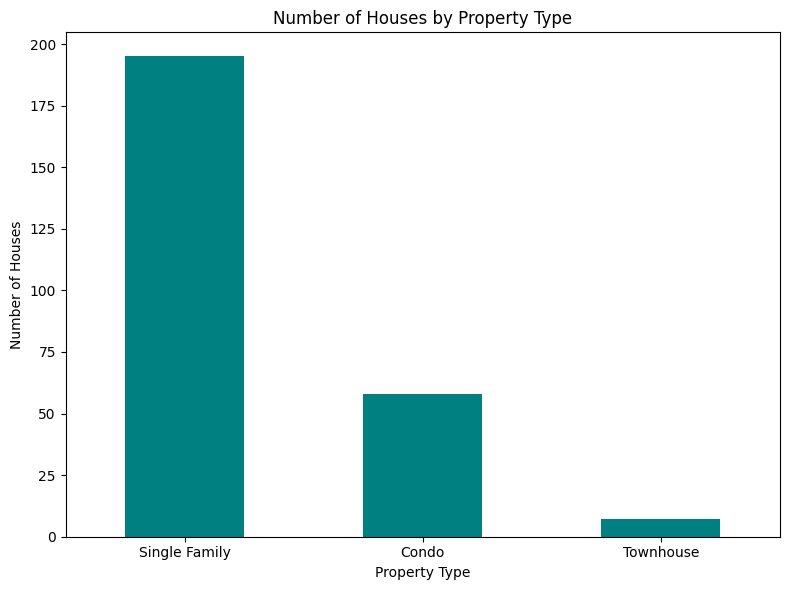

In [207]:
plt.figure(figsize=(8,6))
cleanData['PropType'].value_counts().plot(kind='bar', color = 'teal')
plt.title("Number of Houses by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Number of Houses")
plt.xticks(rotation=0)
plt.tight_layout()

Compute the correlation matrix and use a heat map to visualize the correlation coefficients.

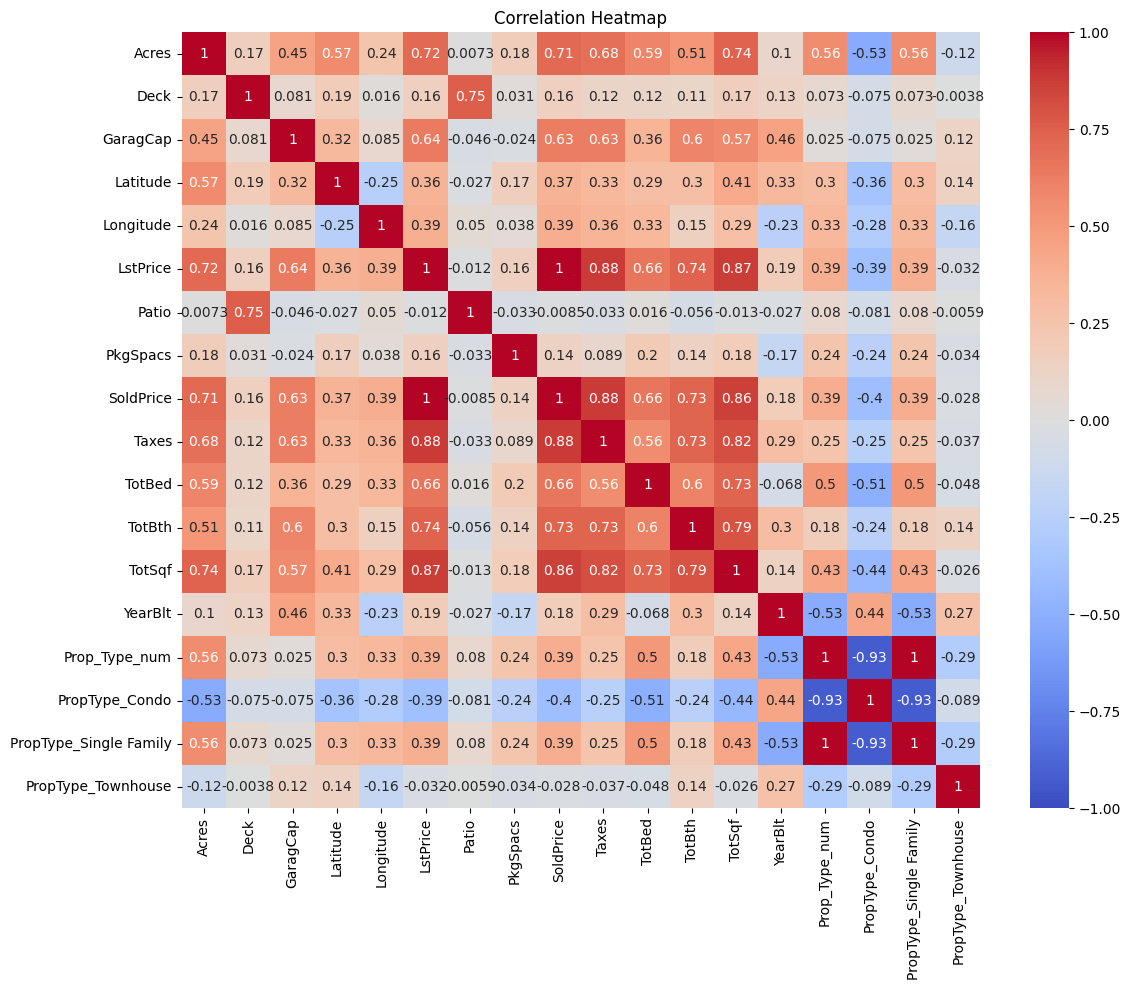

In [208]:
plt.figure(figsize=(12,10))
corr = cleanData.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")

plt.tight_layout()

Create scatter plot and describe corrleations

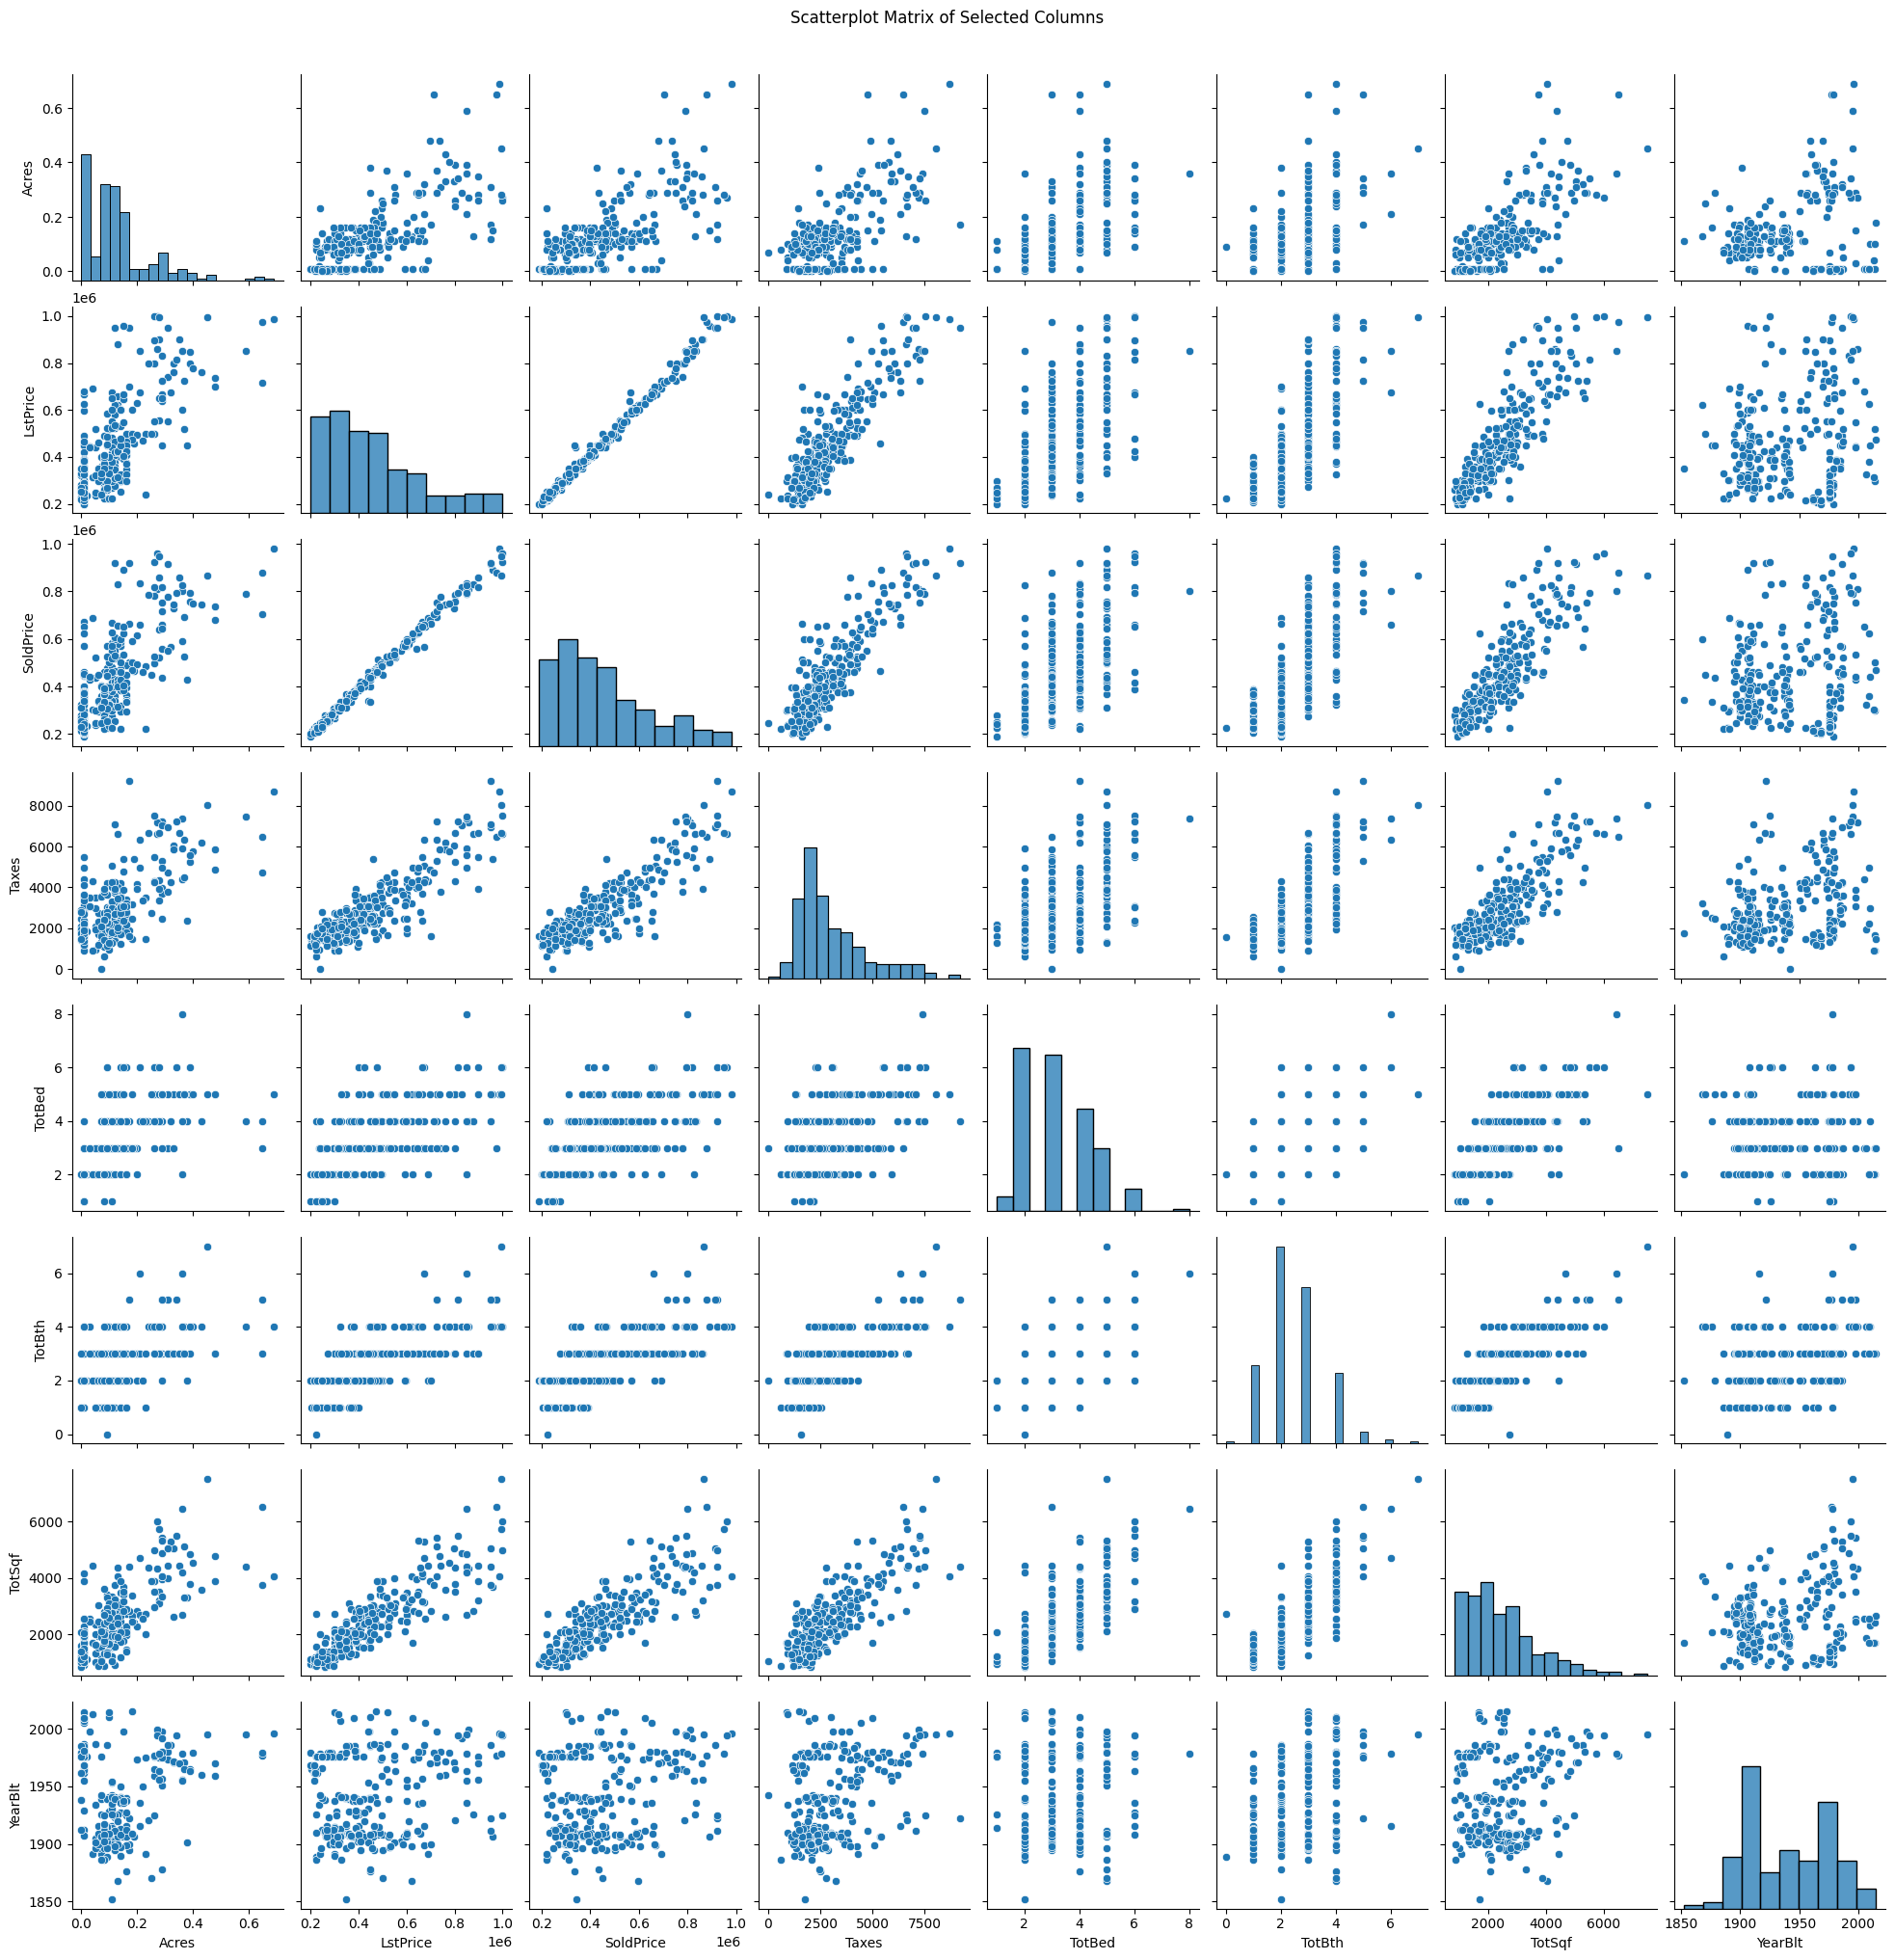

In [209]:
columnSubPlot = ['Acres', 'LstPrice', 'SoldPrice', 'Taxes', 'TotBed', 'TotBth', 'TotSqf', 'YearBlt']
sns.pairplot(cleanData[columnSubPlot])

plt.suptitle("Scatterplot Matrix of Selected Columns", y=1.02)
plt.show()

When analyzing the scatterplots there are several notable correlations.
For strong correlations we have a few relationships:
1. The listing prices (LstPrice) has a very strong correlation with the price that houses were sold(SoldPrice)
2. Atleast relatively to the rest the plots illustrate that total square feet of a house (TotSqf) has medium to strong correlation to price listing(LstPrice), sold price of houses (SoldPrice) as well has a slightly less trong correlation with taxes(Taxes.)

The rest of the correlations are definitly weak when illustrating the relationships with scatterplots.

### Task 4: Geospatial plot
Two of the variables are the latitude and longitude of each listing. Salt Lake City is on this nice east-west, north south grid, so even a simple plot of lat and long makes sense. Create a scatterplot of these two variables. Use color to indicate the price of the house. How does the price depend on the house location?

What can you say about the relation between the location and the house price?

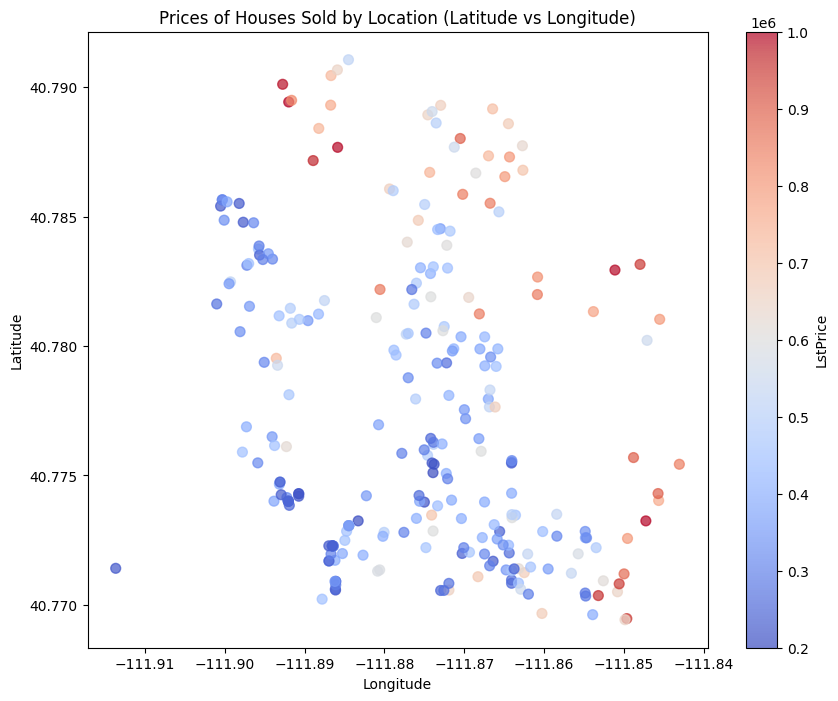

In [210]:
#price of house lat and long 

plt.figure(figsize=(10, 8))
gridplot = plt.scatter(
    cleanData['Longitude'], 
    cleanData['Latitude'], 
    c=cleanData['LstPrice'],    
    cmap='coolwarm',              
    s=50,                        # point sice
    alpha=0.7                    # opacity
)

cbar = plt.colorbar(gridplot)
cbar.set_label('LstPrice')

plt.title('Prices of Houses Sold by Location (Latitude vs Longitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


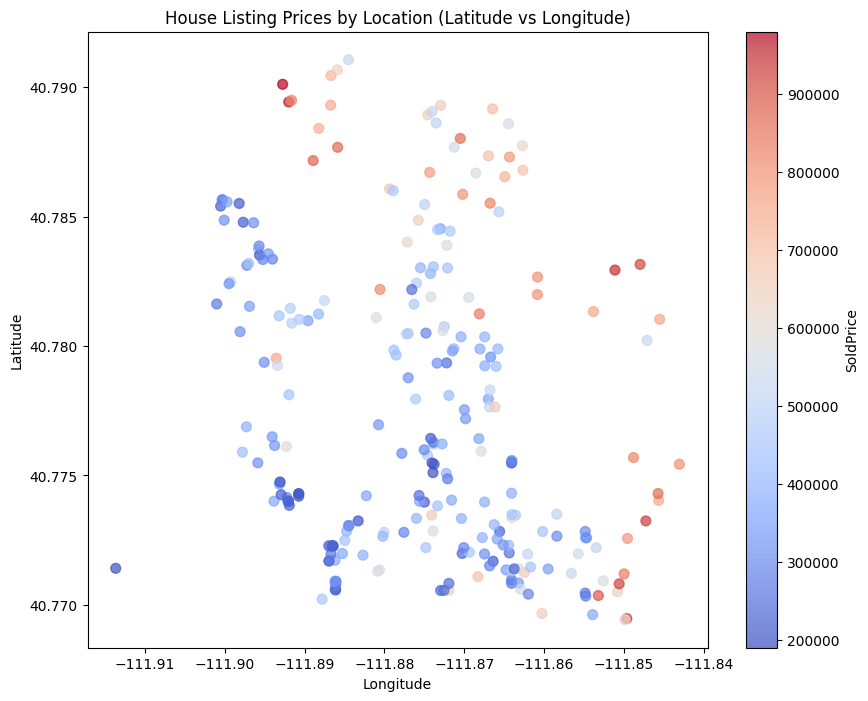

In [ ]:


plt.figure(figsize=(10, 8))
gridplot = plt.scatter(
    cleanData['Longitude'], 
    cleanData['Latitude'], 
    c=cleanData['SoldPrice'],    
    cmap='coolwarm',              
    s=50,                        # point sice
    alpha=0.7                    # opacity
)

cbar = plt.colorbar(gridplot)
cbar.set_label('SoldPrice')

plt.title('House Listing Prices by Location (Latitude vs Longitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

The Scatter plots for representing salt lake city valley as a grid with longitude and latitude illustrate that houses tend be listed for more money on the east or longitudanly.Living here your whole life you can probably infer that the North and Northeast part of the plot is the Avenues, I know that Larry H Miller and some really weathly people live right at the pinnicle of the mountain, the mansions are undoubtebly expensive. It is hard to say just by looking at the plots but it also looks like houses that are listed for the most money often were not able to be sold at that price when using the color to create a narrative.  

### Task 5: Simple Linear Regression
Use the 'ols' function from the statsmodels package to regress the Sold price on some of the other variables. Your model should be of the form Sold Price = beta_0 + beta_1 * x, where x is one of the other variables.

You'll find that the best predictor of sold price is the list price. Report the R-squared value for this model (SoldPrice ~ LstPrice) and give an interpretation for its meaning. Also give an interpretation of beta_1 for this model. Make a plot of list price vs. sold price and overlay the prediction coming from your regression model.

                            OLS Regression Results                            
Dep. Variable:              SoldPrice   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 2.611e+04
Date:                Sat, 31 May 2025   Prob (F-statistic):          2.97e-261
Time:                        19:20:40   Log-Likelihood:                -2927.2
No. Observations:                 260   AIC:                             5858.
Df Residuals:                     258   BIC:                             5866.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.317e+04   2948.953      4.465      0.0

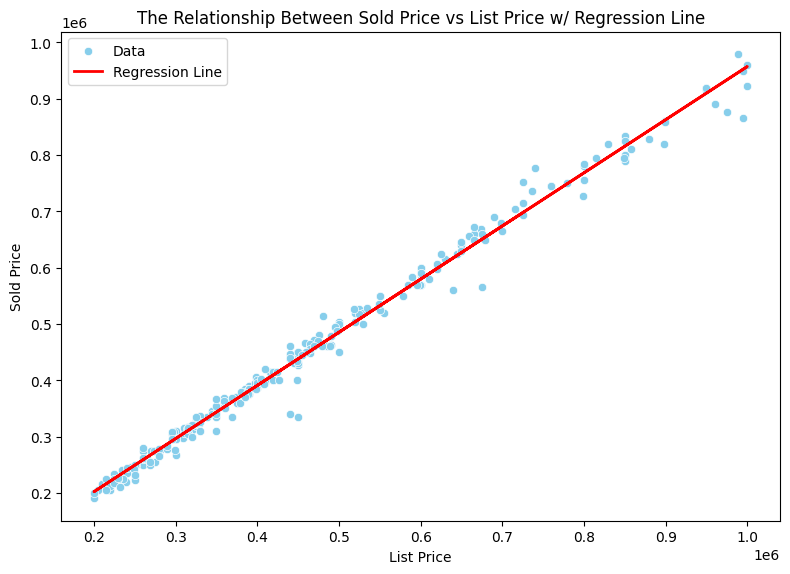

In [212]:
import statsmodels.api as sm

import statsmodels.formula.api as smf
results = smf.ols('SoldPrice ~ LstPrice', data=cleanData).fit()
print(results.summary())

plt.figure(figsize=(8, 6))
sns.scatterplot(x='LstPrice', y='SoldPrice', data=cleanData, color='skyblue', label='Data')
predicted = results.predict(cleanData['LstPrice'])
plt.plot(cleanData['LstPrice'], predicted, color='red', linewidth=2, label='Regression Line')

plt.title('The Relationship Between Sold Price vs List Price w/ Regression Line')
plt.xlabel('List Price')
plt.ylabel('Sold Price')
plt.legend()

plt.tight_layout()
plt.show()


The summary provides a R-squared value of 0.99. This indicates an extremely strong relationship between List Price and Sold Price. The LstPrice (beta1) coef is .9441, this means that for every $1 increase in listing price the Sold Price increases $0.94 on average. The intercept or beta0 is: 1.317e+04 or approximately $13170, which indicates that if there was a house listed at $0.00 it would sell for $13,170, which is of course riduclous and not going to happen. 

### Task 6: Multilinear Regression
Develop a multilinear regression model for house prices in this neighborhood. We could use this to come up with a list price for houses coming on the market, so do not include the list price in your model and, for now, ignore the categorical variable Prop_Type. Your model should be of the form:

Sold Price = beta_0 + beta_1 * x_1 + beta_2 * x_2 + ... +  beta_n * x_n 

In [221]:

variableList= ['Acres', 'Deck', 'GaragCap', 'Latitude', 'Longitude', 'Patio', 'PkgSpacs', 'Taxes', 'TotBed', 'TotBth', 'TotSqf', 'YearBlt']

#Sold Price = beta_0 + beta_1 * x_1 + beta_2 * x_2 + ... +  beta_n * x_n 
sldPrice = 'SoldPrice ~ ' + ' + '.join(variableList)
print(sldPrice)
multiLinearRModel = smf.ols(sldPrice, data=cleanData).fit()

print(multiLinearRModel.summary())
print(cleanData['TotSqf'].describe())




SoldPrice ~ Acres + Deck + GaragCap + Latitude + Longitude + Patio + PkgSpacs + Taxes + TotBed + TotBth + TotSqf + YearBlt
                            OLS Regression Results                            
Dep. Variable:              SoldPrice   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     119.6
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.50e-95
Time:                        19:25:05   Log-Likelihood:                -3279.3
No. Observations:                 260   AIC:                             6585.
Df Residuals:                     247   BIC:                             6631.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------

Question 1: Which variables are the best predictors for the Sold Price?
1) The following variables are good predictors due to having pValues (< .05) that are significant: GaragCap, Longitude, Taxes an TotSqf. We can say with 99% confidence that each of these variables are good predictors for Sold Prices of houses.
Specific questions:

Question 2: Often the price per square foot for a house is advertised. Is this what the coefficient for TotSqf is measuring? Provide an interpretation for the coefficient for TotSqf.

2) The coefficient for TotSqf is $41.41, this indicates that each additional square foot increases SoldPrice by about $41.41, the other variables still have an influene on SoldPrice though.

Question 3: Estimate the value that each Garage space adds to a house.

3)  The coefficient for GaragCap is 2.3281e+04 or $23,810.0. Increasing the garage capacity 1 on average increases the SoldPrice by about $23,810.

Question 4: Does latitude or longitude have an impact on house price? Explain.

4) Yes, Longitude has an impact on house price, the pvalue <.05, this indicates that longitude has a highly signifcant affect on SoldPrice. Latitude, however, doesn't have a significant affect on SoldPrice, P = .0196.

Question 5: If we wanted to start a 'house flipping' company, we'd have to be able to do a better job of predicting the sold price than the list price does. How does your model compare?

5) Interestingly enough, the multilinear Regression model represents a good amount of variance in soldPrice with the R-squared value of .853, this isn't as strong of a predictor as the 'LstPrice' but it still does a good job!

### Task 7: Incorporating a categorical variable
Above, we considered houses, townhouses, and condos together, but here we'll distinguish between them. Consider the two regression models:

SoldPrice = beta_0 + beta_1 * Prop_Type_num and SoldPrice = beta_0  + beta_1 * Prop_Type_num + beta_2 * TotSqf

From the first model, it would appear that Property type is significant in predicting the sold price. On the other hand, the second model indicates that when you take into account total square footage, property type is no longer predictive. Explain this. (Hint: there is a confounder lurking here.) Make a scatterplot of TotSqf vs. SoldPrice where the house types are colored differently to illustrate your explanation.

In [214]:
onlyPropNumModel = smf.ols('SoldPrice ~ Prop_Type_num', data =cleanData).fit()
# print(onlyPropNumModel.pvalues)
print(onlyPropNumModel.summary())



                            OLS Regression Results                            
Dep. Variable:              SoldPrice   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     47.67
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.90e-11
Time:                        19:20:41   Log-Likelihood:                -3506.7
No. Observations:                 260   AIC:                             7017.
Df Residuals:                     258   BIC:                             7025.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       3.21e+05   2.17e+04     14.790

In first model, the coefficient for Prop_Type_num was approximately $173,000 with a p-value of ~0.000.Since the p-value was < 0.05, we conclude that Prop_Type_num was a significant predictor of SoldPrice, suggesting that property type affects housing prices.


In [215]:
PropNumAndTotsqftModel = smf.ols('SoldPrice ~ Prop_Type_num + TotSqf', data = cleanData).fit()
print(PropNumAndTotsqftModel.summary())

                            OLS Regression Results                            
Dep. Variable:              SoldPrice   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     367.2
Date:                Sat, 31 May 2025   Prob (F-statistic):           4.55e-76
Time:                        19:20:41   Log-Likelihood:                -3353.2
No. Observations:                 260   AIC:                             6712.
Df Residuals:                     257   BIC:                             6723.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1.147e+05   1.48e+04      7.755

In second model, where we take in both Property Type and Total Square Feet(Totsqf)into consideration the coefficient for Prop_Type_num was approximately $12,420 with a p-value of ~0.422.Since the p-value was > 0.05, we conclude that Prop_Type_num wasn't a significant predictor of SoldPrice when taking Totsqf into consideration as well. However, it appears that TotSqf is a strong predictor for SoldPrice still, this is backed by the highly signficant Pvalue: 0.000 (P <.05), additionally, the data suggests that every square foot the SoldPrice goes up by $131.90.

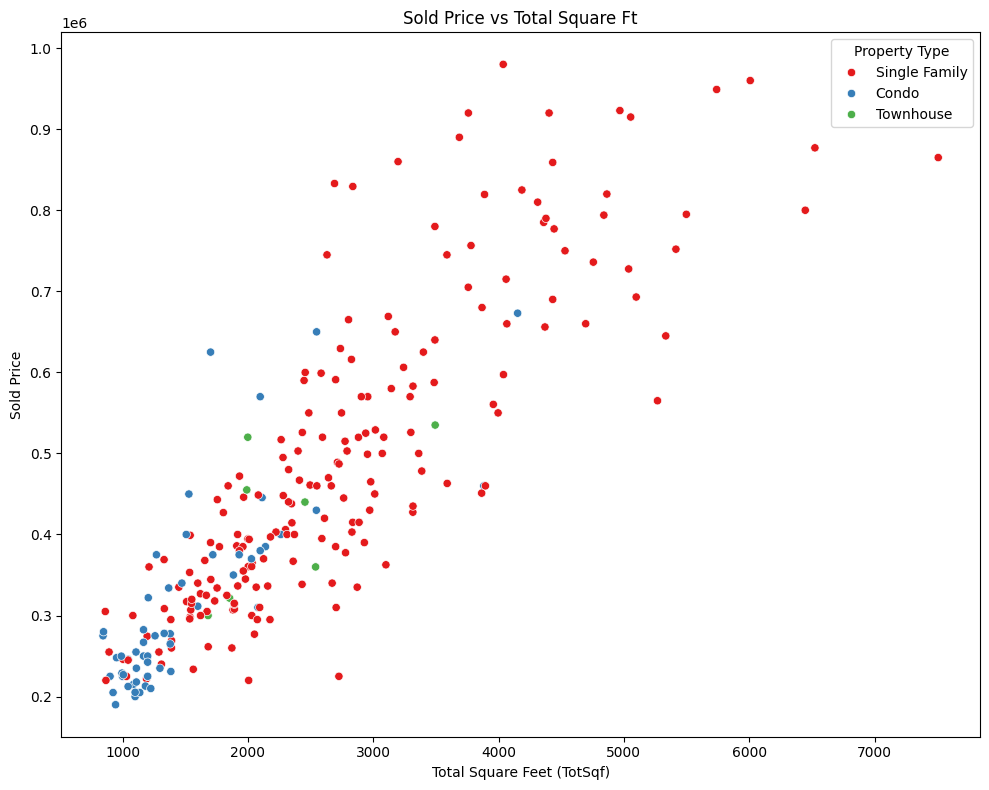

In [216]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
        x='TotSqf',
        y='SoldPrice',
        hue='PropType',      
        data=cleanData,
        palette='Set1'
    )

plt.title('Sold Price vs Total Square Ft')
plt.xlabel('Total Square Feet (TotSqf)')
plt.ylabel('Sold Price')
plt.legend(title='Property Type')
plt.tight_layout()
plt.show()


Together with the model summaries and the scatterplot, we can infer that 'TotSqf' is acting as a confounding variable. When looking at Single Family Property we can recognize that it tends to have a larger Total Square Feet. This suggests that Total Square Feet is the true predictor/underlying factor driving up SoldPrice and that Single Family Properties have a higher 'TotSqf' on average.